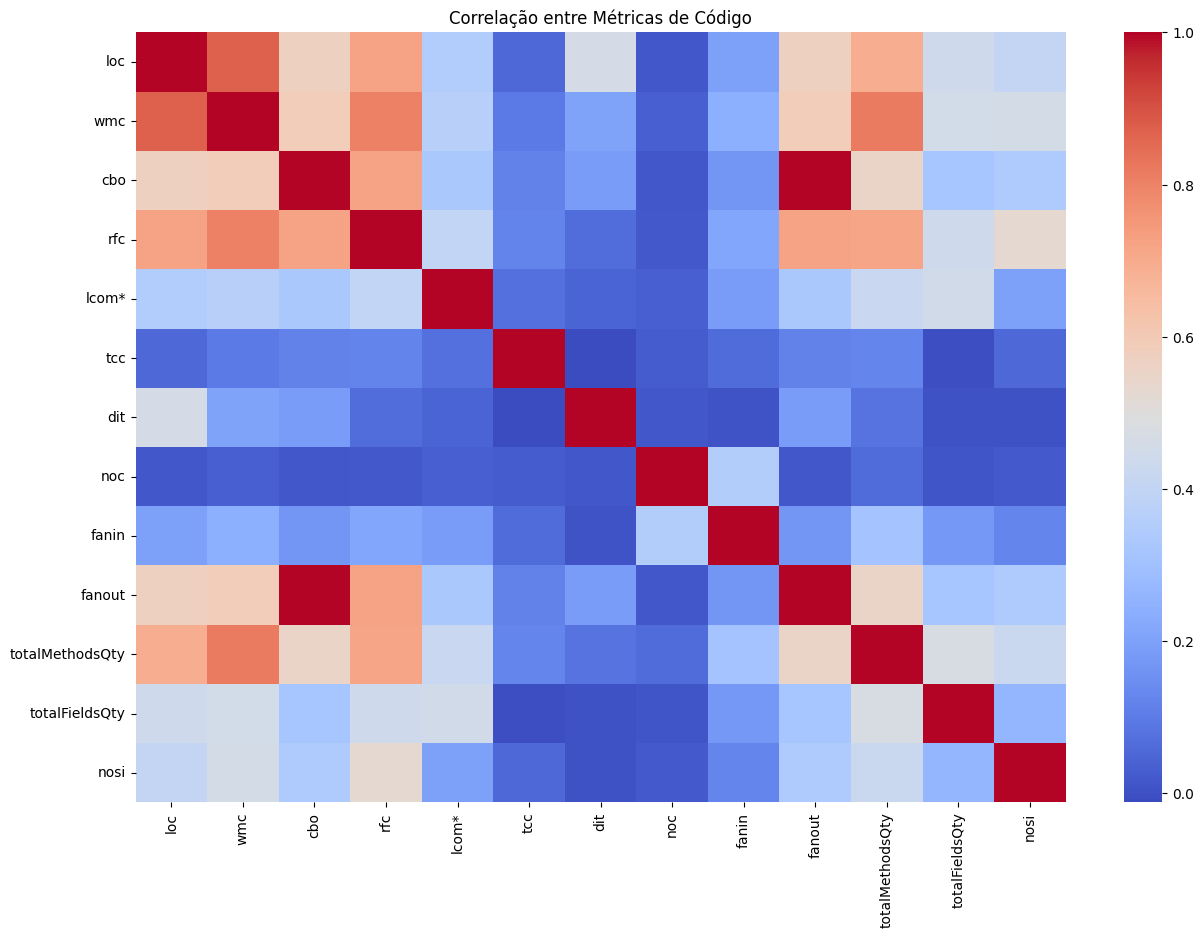

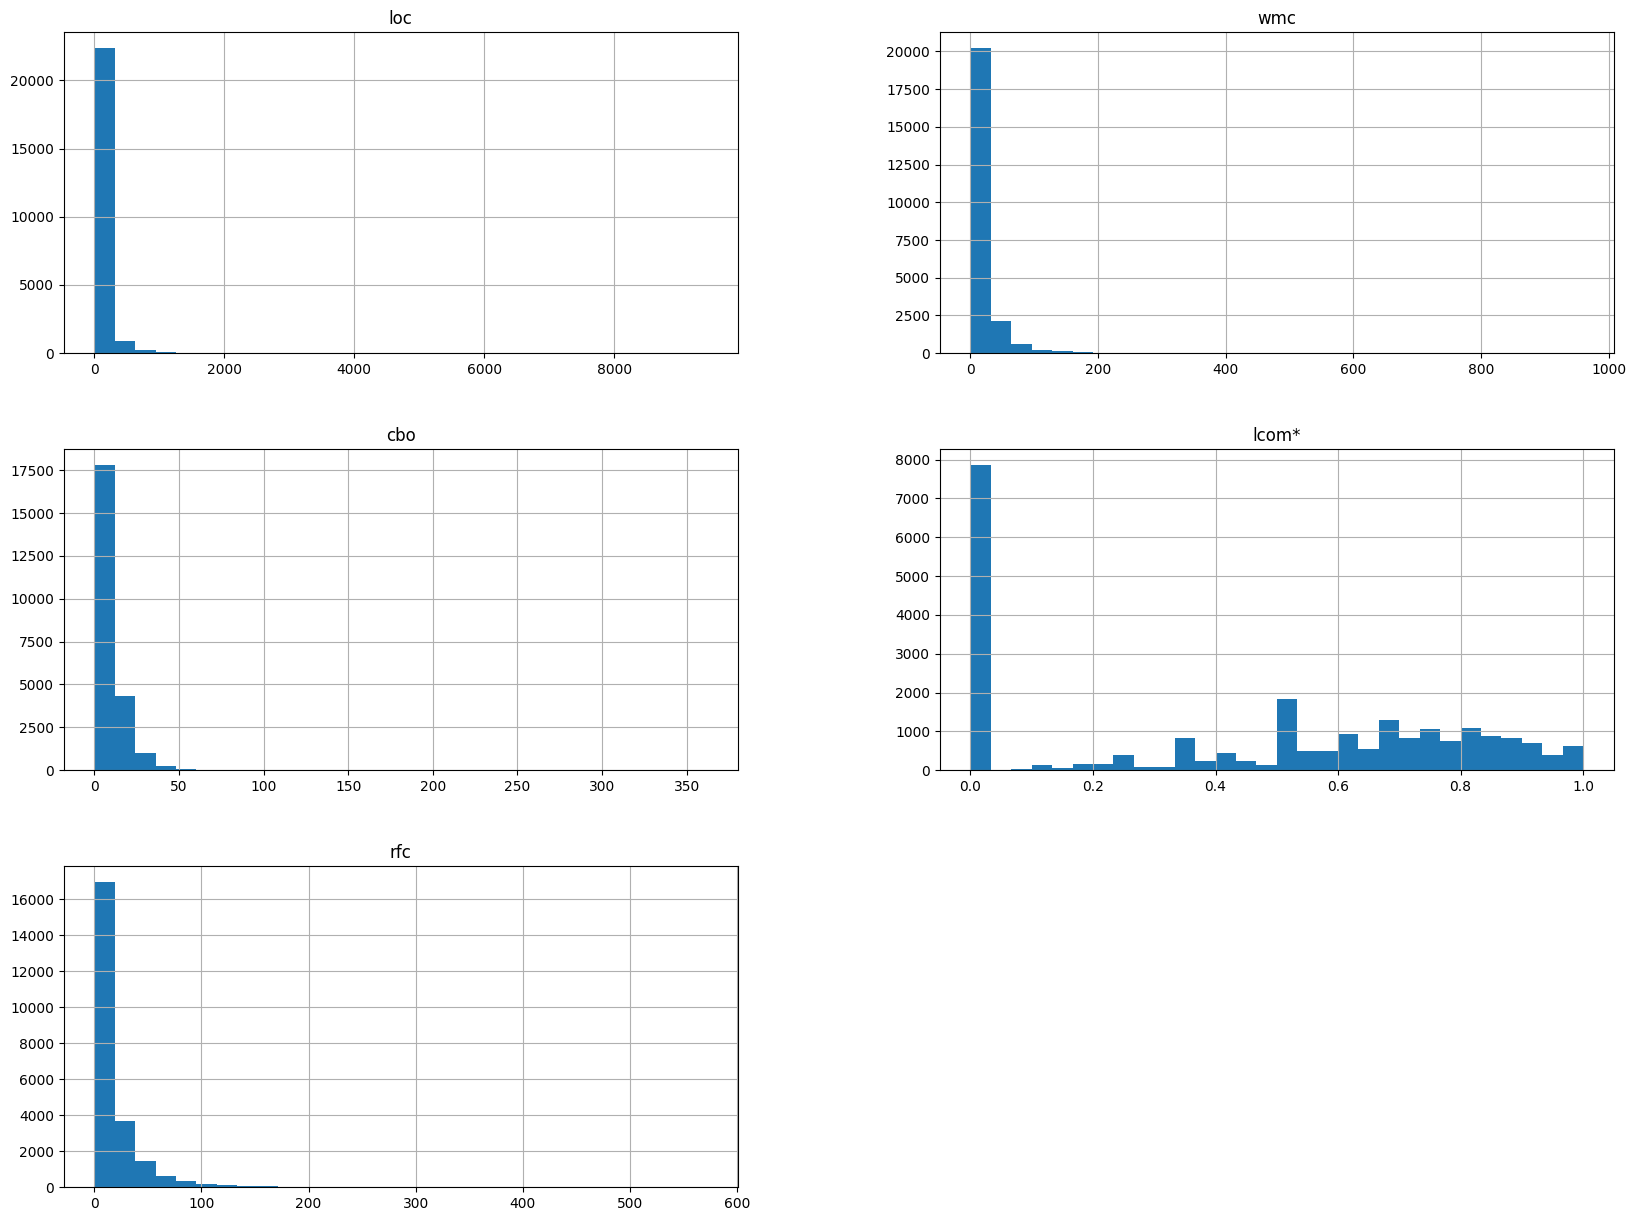

     loc  wmc  cbo  rfc  lcom*  tcc  dit  noc  fanin  fanout  totalMethodsQty  \
min  0.0  0.0  0.0  0.0    0.0  0.0  0.0  0.0    0.0     0.0              0.0   
max  1.0  1.0  1.0  1.0    1.0  0.0  1.0  1.0    1.0     1.0              1.0   

     totalFieldsQty  nosi  
min             0.0   0.0  
max             1.0   1.0  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Carrega o dataset
df = pd.read_csv('dataset_final.csv')
# Manter apenas classes reais, ignorando interfaces e enums
if 'type' in df.columns:
    df = df[df['type'] == 'class'].copy()

# Seleciona apenas as métricas de código
metricas_alvo = [
    'loc', 'wmc', 'cbo', 'rfc', 'lcom*', 'tcc', 'dit', 'noc',
    'fanin', 'fanout', 'totalMethodsQty', 'totalFieldsQty', 'nosi'
]

# Criar o X apenas com essas colunas
X = df[[col for col in metricas_alvo if col in df.columns]].copy()

# Tratamento de dados
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Matriz de Correlação de Métricas
plt.figure(figsize=(15, 10))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm')
plt.title("Correlação entre Métricas de Código")
plt.show()

# Distribuição de Complexidade e Linhas de Código - Apenas das métricas mais comuns
X[[
    'loc', 'wmc', 'cbo', 'lcom*', 'rfc'
]].hist(bins=30, figsize=(20, 15))
plt.show()

# Aplicar logaritmo
X_log = np.log1p(X.clip(lower=0))

# Substituir Infinitos por NaN e depois por 0
X_clean = X_log.replace([np.inf, -np.inf], np.nan).fillna(0)

# aplicar o Scaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_clean)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.describe().loc[['min', 'max']])

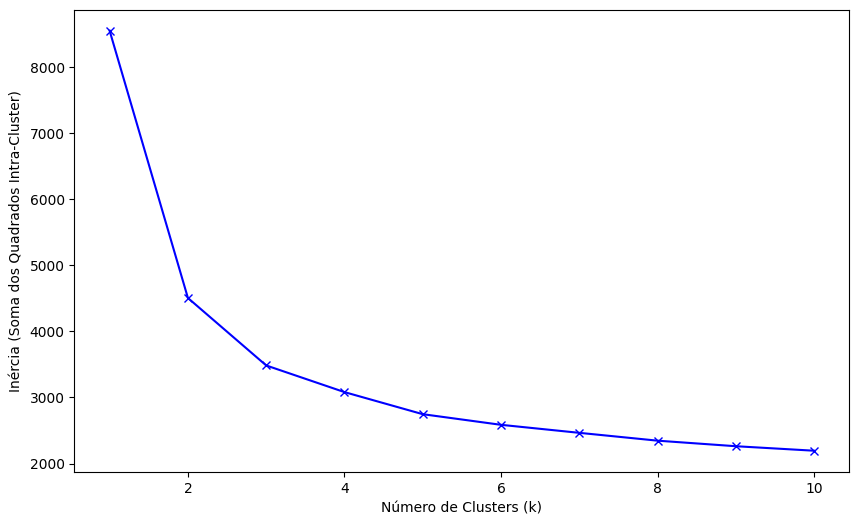

In [12]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Soma dos Quadrados Intra-Cluster)')
plt.show()

In [4]:
k_escolhido = 4 #com base no método do cotovelo
kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# Ver a distribuição de smells por cluster
analise_smells = df.groupby('cluster')['has_smell'].mean() * 100
print("Porcentagem de classes com Smells por Cluster:")
print(analise_smells)

Porcentagem de classes com Smells por Cluster:
cluster
0    24.468418
1    42.292089
2    23.357048
3    29.061554
Name: has_smell, dtype: float64


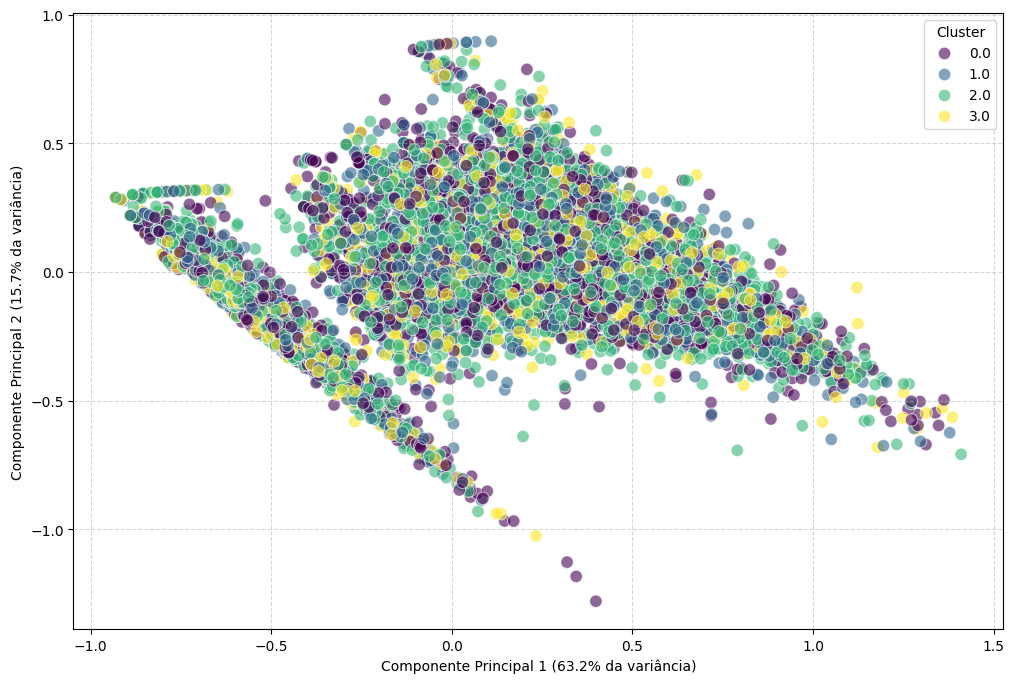

In [6]:
from sklearn.decomposition import PCA
import numpy as np

# Rodar o PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Criar um novo DataFrame para facilitar o plot
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['cluster']  # Recupera os clusters gerados pelo KMeans

# Visualização
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    s=80
)

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
import numpy as np

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("Principais métricas que compõem o PC1 (Eixo X):")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\nPrincipais métricas que compõem o PC2 (Eixo Y):")
print(loadings['PC2'].sort_values(ascending=False).head(5))

Principais métricas que compõem o PC1 (Eixo X):
lcom*             0.702810
rfc               0.326655
totalFieldsQty    0.285420
wmc               0.279632
loc               0.255200
Name: PC1, dtype: float64

Principais métricas que compõem o PC2 (Eixo Y):
lcom*             6.230406e-01
totalFieldsQty    1.297701e-01
tcc              -8.673617e-19
noc              -2.022110e-03
dit              -5.508885e-03
Name: PC2, dtype: float64


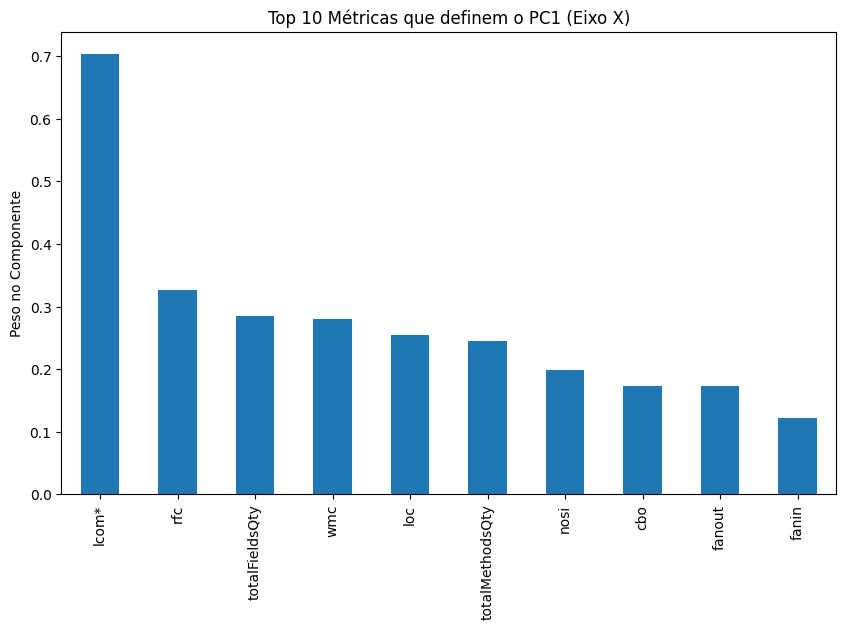

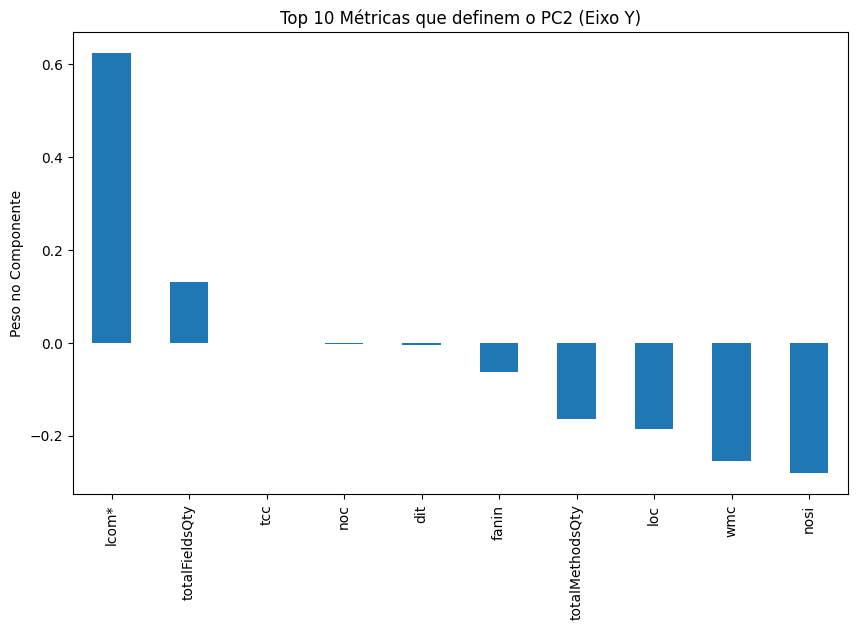

In [8]:
plt.figure(figsize=(10, 6))
loadings['PC1'].sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Métricas que definem o PC1 (Eixo X)')
plt.ylabel('Peso no Componente')
plt.show()

plt.figure(figsize=(10, 6))
loadings['PC2'].sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Métricas que definem o PC2 (Eixo Y)')
plt.ylabel('Peso no Componente')
plt.show()

In [13]:
# Criar uma lista dos nomes dos smells presentes no dataset
smells_cols = [
    'Broken Hierarchy',
    'Broken Modularization',
    'Cyclic Hierarchy',
    'Cyclically-dependent Modularization',
    'Deep Hierarchy',
    'Deficient Encapsulation',
    'Feature Envy',
    'Hub-like Modularization',
    'Imperative Abstraction',
    'Insufficient Modularization',
    'Missing Hierarchy',
    'Multifaceted Abstraction',
    'Multipath Hierarchy',
    'Rebellious Hierarchy',
    'Unexploited Encapsulation',
    'Unnecessary Abstraction',
    'Unutilized Abstraction',
    'Wide Hierarchy'
]

# Perfil de metricas por cluster
perfil_metricas = df.groupby('cluster')[['loc', 'wmc', 'cbo', 'rfc', 'lcom*', 'lcom', 'tcc', 'dit', 'noc', 'fanin', 'fanout', 'totalMethodsQty', 'totalFieldsQty', 'nosi']].mean()
print("Média de Métricas por Cluster:")
display(perfil_metricas)

# Ocorrência de smells por cluster
perfil_smells = df.groupby('cluster')[smells_cols].mean()
print("\nFrequência de Code Smells por Cluster:")
display(perfil_smells)

Média de Métricas por Cluster:


,loc,wmc,cbo,rfc,lcom*,lcom,tcc,dit,noc,fanin,fanout,totalMethodsQty,totalFieldsQty,nosi
cluster,,,,,,,,,,,,,,
0,214.563946,45.867886,18.406660,45.781895,0.774975,222.176048,-0.000156,2.229049,0.342089,5.267980,18.406660,19.086617,8.908537,8.957942
1,12.946045,2.278499,3.643002,1.620892,0.011747,1.325558,-0.096349,1.935700,0.203043,1.351724,3.643002,1.898174,0.821704,0.199391
2,50.618473,8.987339,6.578198,8.457977,0.605820,9.435186,-0.044134,1.967925,0.255999,2.509345,6.578198,5.814181,3.300012,1.077535
3,51.006559,11.710646,9.536831,14.031786,0.040065,46.933401,-0.000757,2.041120,0.236882,2.157921,9.536831,5.854440,0.717457,2.782795



Frequência de Code Smells por Cluster:


,Broken Hierarchy,Broken Modularization,Cyclic Hierarchy,Cyclically-dependent Modularization,Deep Hierarchy,Deficient Encapsulation,Feature Envy,Hub-like Modularization,Imperative Abstraction,Insufficient Modularization,Missing Hierarchy,Multifaceted Abstraction,Multipath Hierarchy,Rebellious Hierarchy,Unexploited Encapsulation,Unnecessary Abstraction,Unutilized Abstraction,Wide Hierarchy
cluster,,,,,,,,,,,,,,,,,,
0,0.020794,0.000156,0.002971,0.037836,0.000000,0.123202,0.012039,0.001251,0.001094,0.068949,0.002502,0.001407,0.000000,0.000469,0.001720,0.001251,0.066917,0.000938
1,0.072819,0.014402,0.000203,0.004260,0.000406,0.028195,0.000203,0.000000,0.000406,0.000000,0.000203,0.000203,0.000000,0.000000,0.000000,0.061866,0.336714,0.001623
2,0.039551,0.000241,0.000965,0.014711,0.000000,0.091282,0.002171,0.000000,0.000844,0.002291,0.000362,0.001688,0.000121,0.000362,0.000121,0.001568,0.124201,0.001206
3,0.058022,0.000000,0.000505,0.007064,0.000000,0.019425,0.001261,0.000000,0.004036,0.009334,0.000252,0.000000,0.000000,0.000000,0.000252,0.000505,0.234612,0.000757


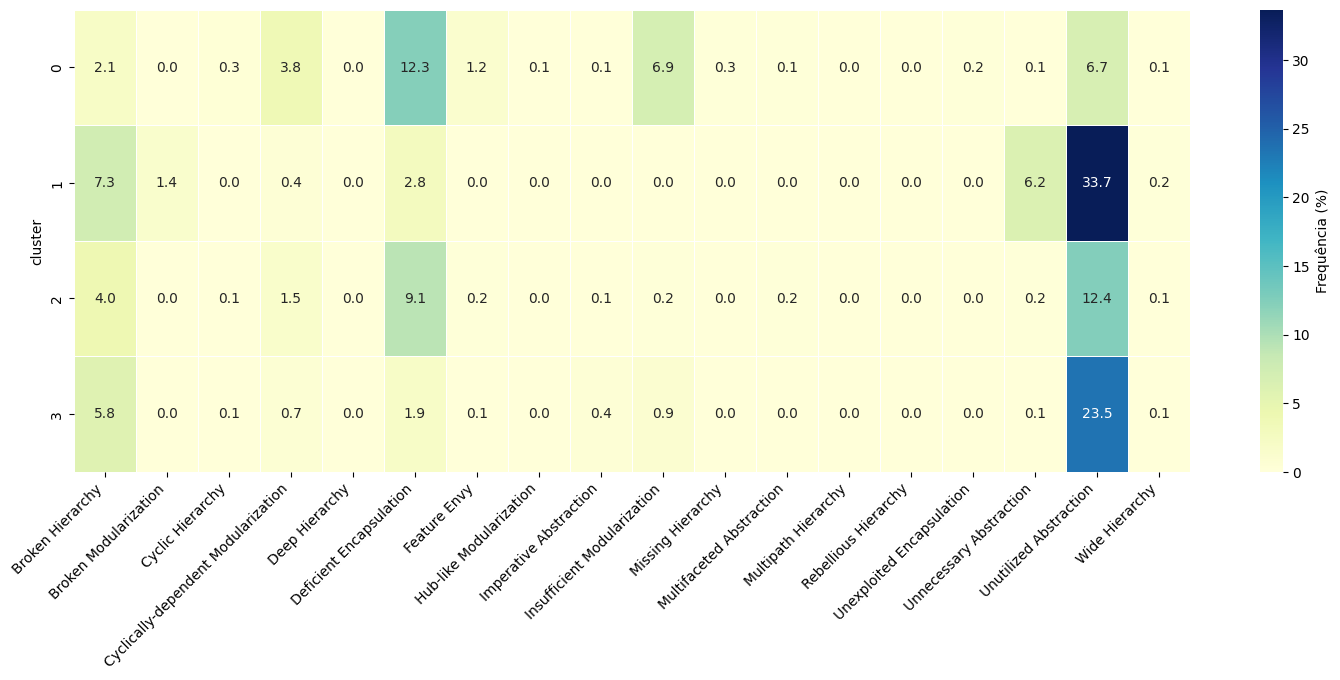

In [15]:
df[smells_cols] = df[smells_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

#calcula a média agrupada por cluster
analise_smells = df.groupby('cluster')[smells_cols].mean() * 100

plt.figure(figsize=(18, 6))
sns.heatmap(
    analise_smells,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Frequência (%)'},
    annot_kws={"size": 10}
)

plt.xticks(rotation=45, ha='right')
plt.show()

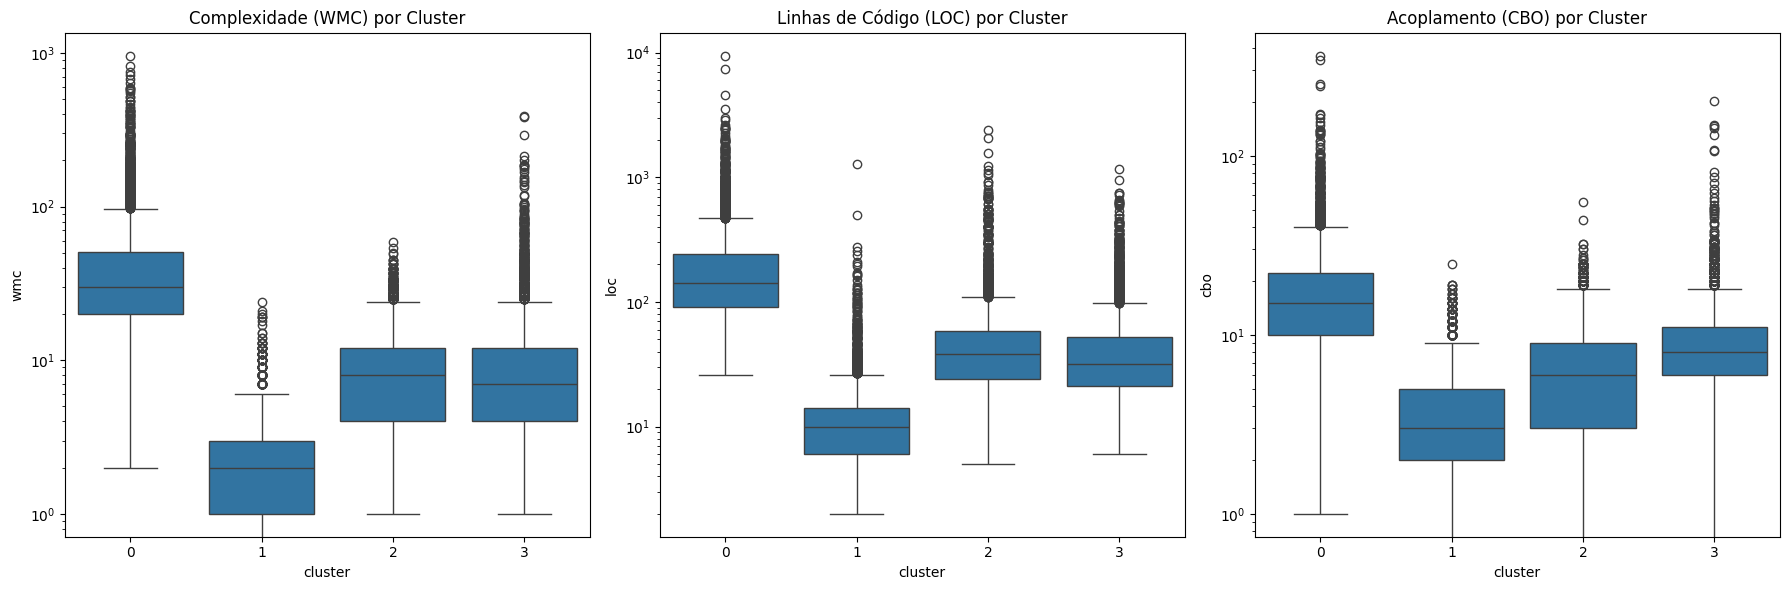

In [14]:
#comparar métricas diferentes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(ax=axes[0], x='cluster', y='wmc', data=df)
axes[0].set_title('Complexidade (WMC) por Cluster')
axes[0].set_yscale('log')

sns.boxplot(ax=axes[1], x='cluster', y='loc', data=df)
axes[1].set_title('Linhas de Código (LOC) por Cluster')
axes[1].set_yscale('log')

sns.boxplot(ax=axes[2], x='cluster', y='cbo', data=df)
axes[2].set_title('Acoplamento (CBO) por Cluster')
axes[2].set_yscale('log')


plt.tight_layout()
plt.show()

In [16]:
smells_presentes = [c for c in smells_cols if c in df.columns]

#Transforma tudo em número (0 ou 1)
df_numeric_smells = df[smells_presentes].apply(pd.to_numeric, errors='coerce').fillna(0)

# Adicionar a coluna de cluster para o agrupamento
df_numeric_smells['cluster'] = df['cluster']

analise_smells = df_numeric_smells.groupby('cluster').mean()

for cluster_id in analise_smells.index:
    linha_cluster = analise_smells.loc[cluster_id]

    # Pega smells com ocorrência acima de 20%
    smells_principais = linha_cluster[linha_cluster >= 0.2].sort_values(ascending=False)

    if not smells_principais.empty:
        lista_smells = ", ".join([f"{s} ({v*100:.1f}%)" for s, v in smells_principais.items()])
        print(f"O Cluster {cluster_id} destaca-se pela presença de: {lista_smells}.\n")
    else:
        # Identifica o smell "menos ausente" para dar um contexto
        print(f"O Cluster {cluster_id} apresenta um design limpo, com baixíssima incidência de smells.\n")

O Cluster 0 apresenta um design limpo, com baixíssima incidência de smells.

O Cluster 1 destaca-se pela presença de: Unutilized Abstraction (33.7%).

O Cluster 2 apresenta um design limpo, com baixíssima incidência de smells.

O Cluster 3 destaca-se pela presença de: Unutilized Abstraction (23.5%).

